In [187]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATA_PATH = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
OUTPUT_PATH = "./processed_data"

TIME_COL = 'ENGINE_RUN_TINE ()'
ID_COL = 'drive_id'

TARGET_COLUMNS = [
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',,
    'COOLANT_TEMPERATURE ()',
    'TIMING_ADVANCE ()',
    'COMMANDED_EVAPORATIVE_PURGE ()',
]

CONTEXT_LENGTH = 96
FORECAST_LENGTH = 48
MIN_DRIVE_LENGTH = CONTEXT_LENGTH + FORECAST_LENGTH
OUT_DIR = "./models/nhits"

TRAIN_SPLIT = 0.7
VALID_SPLIT = 0.15
TEST_SPLIT = 0.15

In [189]:
def load_all_drives(data_path):
    """Load all CSV files from directory."""
    df_list = []
    csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    
    for file in csv_files:
        try:
            df = pd.read_csv(f'{data_path}/{file}', index_col=False)
            df[ID_COL] = file.replace('.csv', '')
            for col in df.columns:
                if col not in [ID_COL, TIME_COL]:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            df_list.append(df)
        except Exception as e:
            print(f"  ⚠️  Skipped {file}: {e}")
    
    data = pd.concat(df_list, ignore_index=True)
    
    return data


In [190]:
def remove_zero_variance_columns(df, exclude_cols=None):
    """Remove columns with no variation."""
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
    
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
    
    if len(zero_variance_cols) > 0:
        print(f"  Removing {len(zero_variance_cols)} zero-variance columns")
        df = df.drop(columns=zero_variance_cols)
    
    return df


def remove_duplicate_timestamps(df, time_col, id_col):
    """Average duplicate timestamps per drive."""
    group_cols = [time_col, id_col]
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
    
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
    
    return df_clean


def filter_short_drives(df, id_col, min_length):
    """Keep only drives long enough for modeling."""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    df_filtered = df[df[id_col].isin(valid_drives)].reset_index(drop=True)
    
    return df_filtered


def handle_missing_values(df, target_cols, id_col):
    """Fill small gaps and remove remaining NaNs."""
    for col in target_cols:
        # Forward fill small gaps (up to 5 timesteps)
        df[col] = df.groupby(id_col)[col].fillna(method='ffill', limit=5)
        
        # Drop rows with remaining NaNs
        before = len(df)
        df = df.dropna(subset=[col])
        dropped = before - len(df)
        
        if dropped > 0:
            print(f"  {col}: Dropped {dropped} rows with NaN")
    
    return df.reset_index(drop=True)


def clean_data(data, target_cols, time_col, id_col, min_length):
    """Apply all cleaning steps."""
    
    data = data.sort_values([id_col, time_col]).reset_index(drop=True)
    
    data = remove_duplicate_timestamps(data, time_col, id_col)
    
    data = remove_zero_variance_columns(data, exclude_cols=[id_col, time_col])
    
    data = handle_missing_values(data, target_cols, id_col)
    
    data = filter_short_drives(data, id_col, min_length)
    
    
    return data

In [191]:
def add_derivative_features(df, target_cols, id_col):
    """Add rate-of-change features."""
    for col in target_cols:
        df[f'{col}_change'] = df.groupby(id_col)[col].diff()
        
        q99 = df[f'{col}_change'].abs().quantile(0.99)
        df[f'{col}_change'] = df[f'{col}_change'].clip(-q99, q99)
        
        df[f'{col}_change'] = df.groupby(id_col)[f'{col}_change'].fillna(0)
    
    return df


def detect_outliers(df, target_cols, n_std=4):
    """Flag outliers using z-score."""
    outlier_mask = pd.Series(False, index=df.index)
    
    for col in target_cols:
        if col in df.columns:
            z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
            outlier_mask |= (z_scores > n_std)
    
    n_outliers = outlier_mask.sum()
    if n_outliers > 0:
        for col in target_cols:
            if col in df.columns:
                q01, q99 = df[col].quantile([0.01, 0.99])
                df[col] = df[col].clip(q01, q99)
    
    return df

In [192]:
def split_by_drives(data, id_col, train_split, valid_split, test_split, seed=42):
    """Split data by drives (not by timesteps)."""
    np.random.seed(seed)
    drive_ids = data[id_col].unique()
    np.random.shuffle(drive_ids)
    
    n_drives = len(drive_ids)
    train_end = int(n_drives * train_split)
    valid_end = int(n_drives * (train_split + valid_split))
    
    train_ids = drive_ids[:train_end]
    valid_ids = drive_ids[train_end:valid_end]
    test_ids = drive_ids[valid_end:]
    
    train_data = data[data[id_col].isin(train_ids)]
    valid_data = data[data[id_col].isin(valid_ids)]
    test_data = data[data[id_col].isin(test_ids)]
    
    return train_data, valid_data, test_data

In [193]:
def convert_to_nhits_format(data, target_cols, time_col, id_col):
    """
    Convert to N-HiTS format with sequential integer time index.
    
    N-HiTS doesn't need actual dates - just consistent spacing.
    Each drive starts at timestep 0.
    """
    all_series = []
    
    for col in target_cols:
        for drive_id in data[id_col].unique():
            drive_data = data[data[id_col] == drive_id].copy()
            
            drive_data = drive_data.sort_values(time_col).reset_index(drop=True)
            
            df_series = pd.DataFrame({
                'unique_id': f"{drive_id}_{col}",
                'ds': np.arange(len(drive_data)),
                'y': drive_data[col].values
            })
            
            df_series = df_series.dropna()
            
            if len(df_series) >= MIN_DRIVE_LENGTH:
                all_series.append(df_series)
    
    nhits_data = pd.concat(all_series, ignore_index=True)
    
    return nhits_data



def convert_splits_to_nhits(train_data, valid_data, test_data, target_cols, time_col, id_col):
    """Convert all splits to N-HiTS format."""
    
    train_nhits = convert_to_nhits_format(train_data, target_cols, time_col, id_col)
    valid_nhits = convert_to_nhits_format(valid_data, target_cols, time_col, id_col)
    test_nhits = convert_to_nhits_format(test_data, target_cols, time_col, id_col)
    
    
    print(f"✓ Train: {train_nhits['unique_id'].nunique()} series, {len(train_nhits):,} samples")
    print(f"✓ Valid: {valid_nhits['unique_id'].nunique()} series, {len(valid_nhits):,} samples")
    print(f"✓ Test:  {test_nhits['unique_id'].nunique()} series, {len(test_nhits):,} samples")
    
    return train_nhits, valid_nhits, test_nhits

In [194]:
 # Step 1: Load
data = load_all_drives(DATA_PATH)

# Step 2: Clean
data = clean_data(data, TARGET_COLUMNS, TIME_COL, ID_COL, MIN_DRIVE_LENGTH)

# Step 3: Feature engineering
data = add_derivative_features(data, TARGET_COLUMNS, ID_COL)
data = detect_outliers(data, TARGET_COLUMNS)

# Step 4: Split
train_data, valid_data, test_data = split_by_drives(
    data, ID_COL, TRAIN_SPLIT, VALID_SPLIT, TEST_SPLIT
)

# Step 5: Convert to N-HiTS format
train_nhits, valid_nhits, test_nhits = convert_splits_to_nhits(
    train_data, valid_data, test_data, TARGET_COLUMNS, TIME_COL, ID_COL
)

  Removing 3 zero-variance columns
✓ Train: 720 series, 438,088 samples
✓ Valid: 152 series, 96,672 samples
✓ Test:  160 series, 124,496 samples


In [195]:
train_val_nhits = pd.concat([train_nhits, valid_nhits], ignore_index=True)
train_val_nhits['unique_id'] = train_val_nhits['unique_id'].astype(str)
train_val_nhits['ds'] = train_val_nhits['ds'].astype(np.int64)
train_val_nhits['y'] = pd.to_numeric(train_val_nhits['y'], errors='coerce')
train_val_nhits = train_val_nhits.dropna(subset=['y'])

assert not train_val_nhits['y'].isna().any(), "Y column has NaN values!"
assert train_val_nhits['y'].dtype in [np.float32, np.float64], f"Y must be float, got {train_val_nhits['y'].dtype}"

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS
from neuralforecast.losses.pytorch import MSE

nhits_model = NHITS(
    h=FORECAST_LENGTH,
    input_size=CONTEXT_LENGTH,
    
    n_pool_kernel_size=[4, 2, 1],
    n_freq_downsample=[16, 8, 1],
    stack_types=['identity', 'identity', 'identity'],
    n_blocks=[2, 2, 2],
    mlp_units=[[1024, 512], [512, 512], [512, 512]],
    
    max_steps=20000,
    batch_size=64,
    learning_rate=1e-3,
    
    scaler_type=None,
    
    enable_progress_bar=True,
    random_seed=42,
)
models = [nhits_model]
nf = NeuralForecast(models=models, freq=1)

nf.fit(df=train_val_nhits)

nf.save(f'{OUT_DIR}/nhits_model.pkl')

print("\n✓ Training complete!")


INFO:p-92105:t-8534990592:seed.py:seed_everything:Seed set to 42
INFO:p-92105:t-8534990592:setup.py:_log_device_info:GPU available: True (mps), used: True
INFO:p-92105:t-8534990592:setup.py:_log_device_info:TPU available: False, using: 0 TPU cores
INFO:p-92105:t-8534990592:model_summary.py:summarize:
  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 7.0 M  | train | 0    
---------------------------------------------------------------
7.0 M     Trainable params
0         Non-trainable params
7.0 M     Total params
28.019    Total estimated model params size (MB)
64        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:p-92105:t-8534990592:fit_loop.py:done:`Trainer.fit` stopped: `max_steps=20000` reached.


Exception: Directory is not empty. Set `overwrite=True` to overwrite files.

In [198]:
train_val_nhits = pd.concat([train_nhits, valid_nhits], ignore_index=True)
train_val_nhits['unique_id'] = train_val_nhits['unique_id'].astype(str)
train_val_nhits['ds'] = train_val_nhits['ds'].astype(np.int64)
train_val_nhits['y'] = pd.to_numeric(train_val_nhits['y'], errors='coerce')
train_val_nhits = train_val_nhits.dropna(subset=['y'])

test_nhits['unique_id'] = test_nhits['unique_id'].astype(str)
test_nhits['ds'] = test_nhits['ds'].astype(np.int64)
test_nhits['y'] = pd.to_numeric(test_nhits['y'], errors='coerce').astype(np.float64)
test_nhits = test_nhits.dropna(subset=['y'])


assert not train_val_nhits['y'].isna().any(), "Y column has NaN values!"
assert train_val_nhits['y'].dtype in [np.float32, np.float64], f"Y must be float, got {train_val_nhits['y'].dtype}"

INFO:p-92105:t-8534990592:setup.py:_log_device_info:GPU available: True (mps), used: True
INFO:p-92105:t-8534990592:setup.py:_log_device_info:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

✓ Saved to nhits_predictions.png


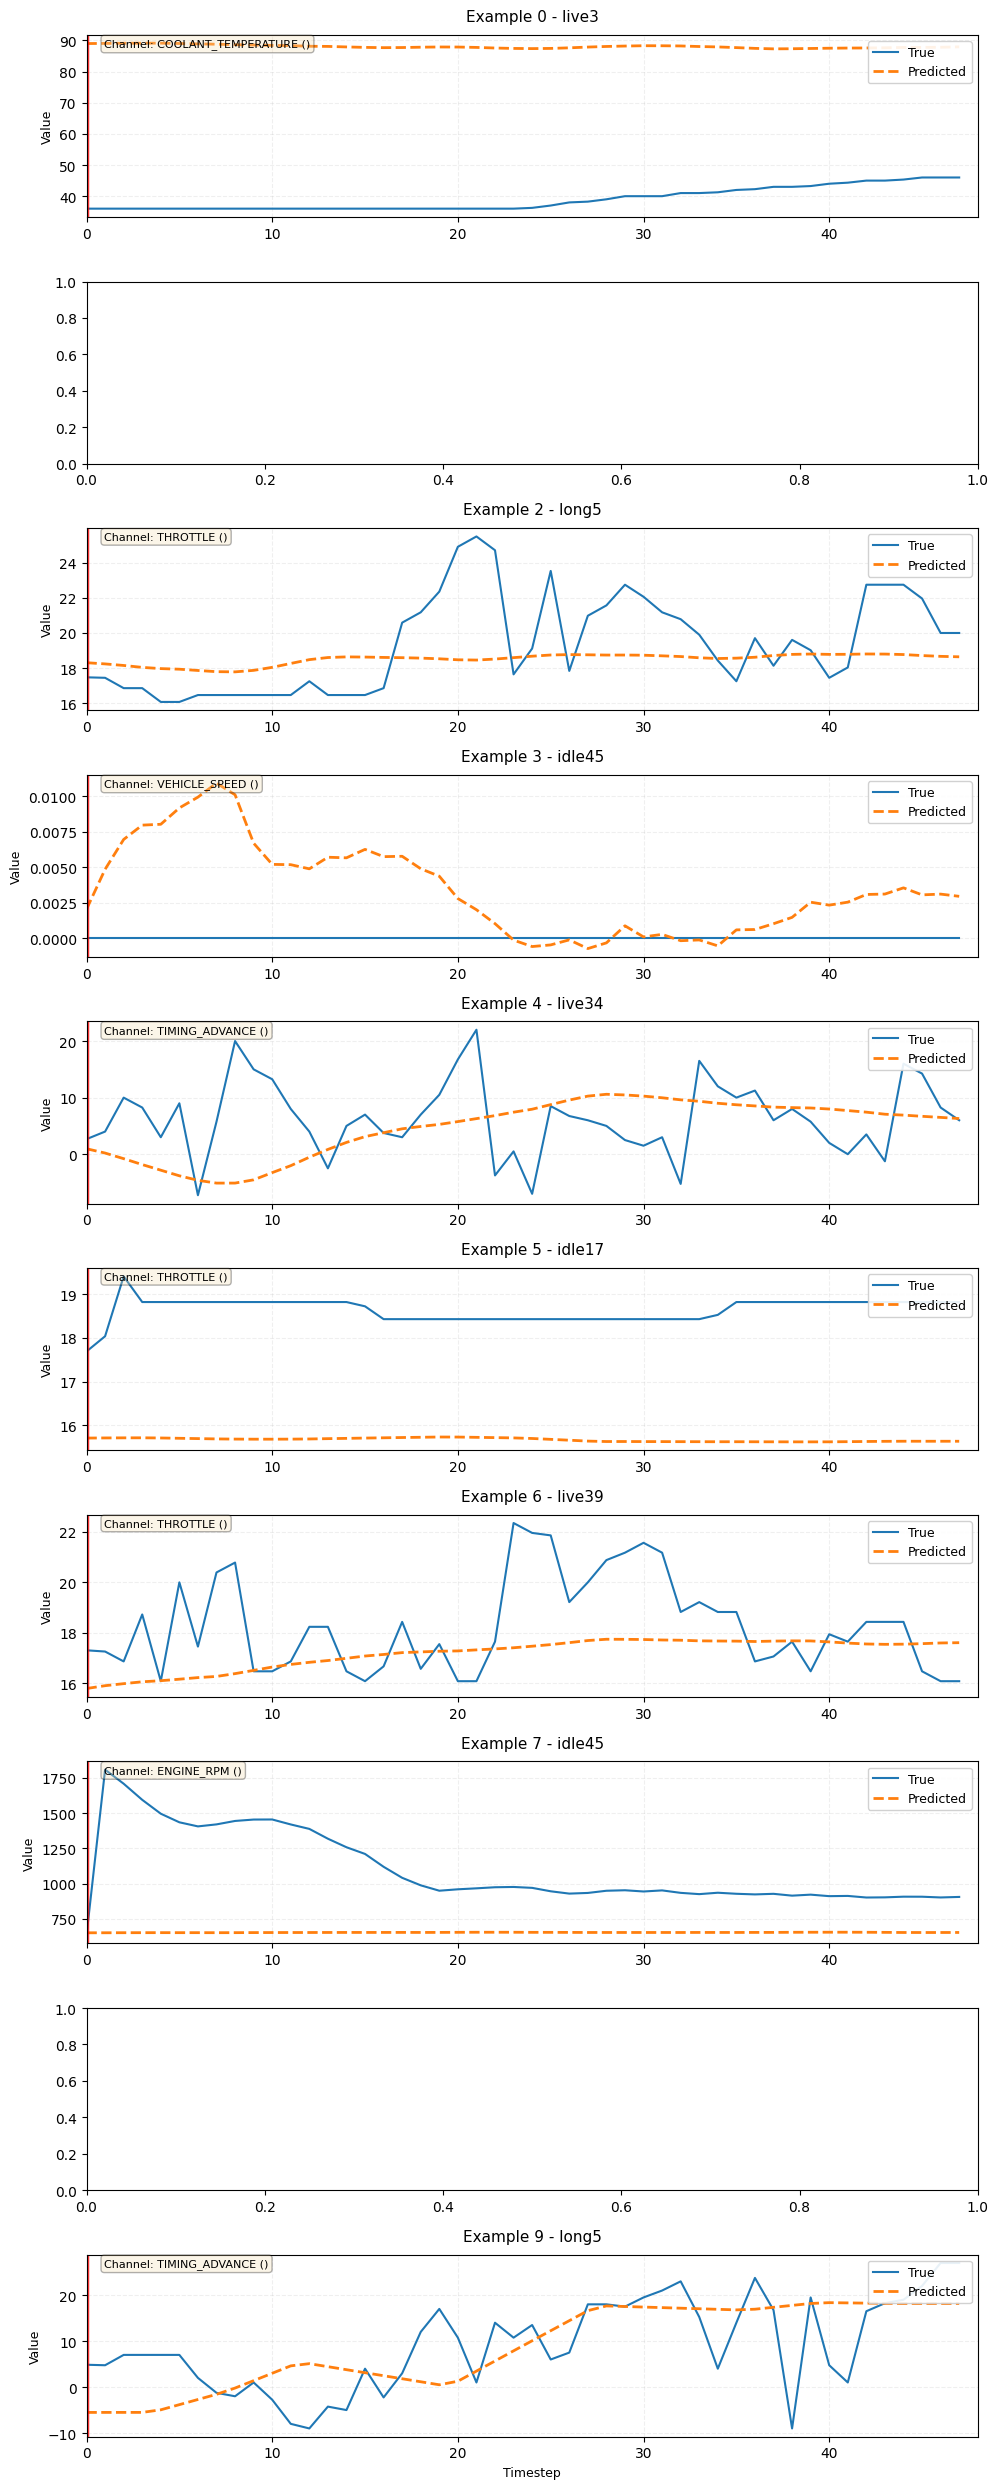

In [199]:
import matplotlib.pyplot as plt

def plot_nhits_predictions_ttm_style(
    forecasts,
    test_data,
    context_data,
    target_columns,
    time_col='ENGINE_RUN_TINE ()',
    id_col='drive_id',
    context_length=512,
    forecast_length=96,
    num_examples=10,
    save_path='nhits_predictions.png'
):
    """
    Plot in exact TTM style with blue solid for true, orange dashed for predicted.
    """
    
    # Get unique series
    unique_series = forecasts['unique_id'].unique()
    np.random.seed(42)
    selected_series = np.random.choice(unique_series, min(num_examples, len(unique_series)), replace=False)
    
    # Create figure
    fig, axes = plt.subplots(num_examples, 1, figsize=(10, 2.5 * num_examples))
    if num_examples == 1:
        axes = [axes]
    
    for idx, series_id in enumerate(selected_series):
        ax = axes[idx]
        
        # Parse series ID
        parts = series_id.split('_')
        drive_id = '_'.join(parts[:-2]) if len(parts) > 2 else parts[0]
        channel = '_'.join(parts[-2:]) if len(parts) > 2 else parts[-1]
        
        # Reconstruct full channel name (add back parentheses if needed)
        matching_channels = [col for col in target_columns if col.replace(' ()', '').replace('_', '') in channel]
        if matching_channels:
            channel = matching_channels[0]
        
        # Get forecast
        series_forecast = forecasts[forecasts['unique_id'] == series_id].sort_values('ds')
        
        # Try different column names for predictions
        if 'NHITS' in series_forecast.columns:
            forecast_values = series_forecast['NHITS'].values
        elif 'y_hat' in series_forecast.columns:
            forecast_values = series_forecast['y_hat'].values
        else:
            # Last numeric column
            numeric_cols = series_forecast.select_dtypes(include=[np.number]).columns
            forecast_values = series_forecast[numeric_cols[-1]].values
        
        # Get ground truth
        drive_test_data = test_data[test_data[id_col] == drive_id].sort_values(time_col).reset_index(drop=True)
        
        if len(drive_test_data) < forecast_length or channel not in drive_test_data.columns:
            continue
        
        true_forecast = drive_test_data[channel].values[:forecast_length]
        
        # Get context
        drive_context_data = context_data[context_data[id_col] == drive_id].sort_values(time_col)
        if len(drive_context_data) >= context_length:
            context_values = drive_context_data[channel].values[-context_length:]
        else:
            context_values = drive_context_data[channel].values
        
        # Combine context + true forecast for continuous blue line
        full_true = np.concatenate([context_values, true_forecast])
        true_x = np.arange(len(full_true))
        
        # Forecast starts after context
        forecast_x = np.arange(len(context_values), len(context_values) + len(forecast_values))
        
        # Plot true (blue solid line)
        ax.plot(true_x, full_true, color='#1f77b4', linewidth=1.5, label='True')
        
        # Plot predicted (orange dashed line)
        ax.plot(forecast_x, forecast_values[:len(true_forecast)], 
                color='#ff7f0e', linestyle='--', linewidth=2, label='Predicted')
        
        # Red vertical line at forecast boundary
        ax.axvline(x=len(context_values), color='red', linestyle='-', linewidth=2.5, alpha=0.8)
        
        # Title and labels
        ax.set_title(f'Example {idx} - {drive_id}', fontsize=11, pad=10)
        ax.set_ylabel('Value', fontsize=9)
        if idx == num_examples - 1:
            ax.set_xlabel('Timestep', fontsize=9)
        
        # Legend
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        
        # Grid
        ax.grid(True, alpha=0.2, linestyle='--')
        
        # Set limits
        ax.set_xlim(0, len(context_values) + forecast_length)
        
        # Add text annotation for channel
        ax.text(0.02, 0.98, f'Channel: {channel}', 
                transform=ax.transAxes, fontsize=8, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    
    return fig

forecasts = nf.predict(df=test_nhits)

context_data = pd.concat([train_data, valid_data], ignore_index=True)

fig = plot_nhits_predictions_ttm_style(
    forecasts=forecasts,
    test_data=test_data,
    context_data=context_data,
    target_columns=TARGET_COLUMNS,
    time_col=TIME_COL,
    id_col=ID_COL,
    context_length=CONTEXT_LENGTH,
    forecast_length=FORECAST_LENGTH,
    num_examples=10
)
